# Thompson Sampling

## Importing the libraries

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [17]:
dataset = pd.read_csv('Ads_CTR_Optimisation.csv')

## Implementing Thompson Sampling

In [18]:
import random
N = 500
d = 10
ads_selected = []
numbers_of_rewards_1 = [0] * d
numbers_of_rewards_0 = [0] * d
total_reward = 0
for n in range(0, N):
  ad = 0
  max_random = 0
  for i in range(0, d):
    random_beta = random.betavariate(numbers_of_rewards_1[i] + 1, numbers_of_rewards_0[i] + 1)
    if random_beta > max_random:
      max_random = random_beta
      ad = i
  ads_selected.append(ad)
  reward = dataset.values[n, ad]
  if reward == 1:
    numbers_of_rewards_1[ad] = numbers_of_rewards_1[ad] + 1
  else:
    numbers_of_rewards_0[ad] = numbers_of_rewards_0[ad] + 1
  total_reward = total_reward + reward

In [19]:
from collections import Counter
ad_clicks = Counter(ads_selected)
print("Number of times each ad was selected:")
for ad_index, count in sorted(ad_clicks.items()):
    print(f"Ad {ad_index + 1}: {count} times")

Number of times each ad was selected:
Ad 1: 26 times
Ad 2: 54 times
Ad 3: 16 times
Ad 4: 25 times
Ad 5: 169 times
Ad 6: 15 times
Ad 7: 41 times
Ad 8: 81 times
Ad 9: 40 times
Ad 10: 33 times


## Visualising the results - Histogram

<function matplotlib.pyplot.show(close=None, block=None)>

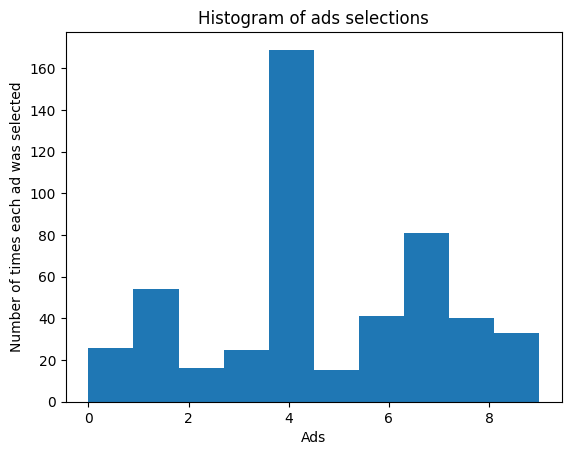

In [20]:
plt.hist(ads_selected)
plt.title('Histogram of ads selections')
plt.xlabel('Ads')
plt.ylabel('Number of times each ad was selected')
plt.show